In [1]:
using Oceananigans
using JLD2
using CairoMakie
using CairoMakie.Colors
using Statistics
using FFTW

include("../src-fig/figures/preinitial_conditions.jl")
include("../src-simulation/parameters.jl")
include("../src-simulation/base_state.jl")
include("../src-simulation/grid_faces.jl")

include("../src-fig/plotting.jl")
include("../setup/ensemble.jl");

[ Info: Oceananigans will use 4 threads


In [2]:
run_ids = cooling_only.filenames
tkes = map(run_ids) do run_id
    TKE = joinpath("../../scratch/turbulence-at-many-fronts", run_id, "TKE.jld2")
    iterations, times = iterations_times(TKE)
    data = timeseries_of(TKE, "tke", iterations) do field
        mean(field)
    end
end
vsps = map(run_ids) do run_id
    TKE = joinpath("../../scratch/turbulence-at-many-fronts", run_id, "TKE.jld2")
    iterations, times = iterations_times(TKE)
    data = timeseries_of(TKE, "vsp", iterations) do field
        mean(field)
    end
end
bfluxs = map(run_ids) do run_id
    TKE = joinpath("../../scratch/turbulence-at-many-fronts", run_id, "TKE.jld2")
    iterations, times = iterations_times(TKE)
    data = timeseries_of(TKE, "bflux", iterations) do field
        mean(field)
    end
end
#=
tkes_L = map(run_ids) do run_id
    TKE = joinpath("../../scratch/turbulence-at-many-fronts", run_id, "TKE-L.jld2")
    iterations, times = iterations_times(TKE)
    data = timeseries_of(TKE, "tke", iterations) do field
        mean(field)
    end
end
vsps_L = map(run_ids) do run_id
    TKE = joinpath("../../scratch/turbulence-at-many-fronts", run_id, "TKE-L.jld2")
    iterations, times = iterations_times(TKE)
    data = timeseries_of(TKE, "vsp", iterations) do field
        mean(field)
    end
end
bfluxs_L = map(run_ids) do run_id
    TKE = joinpath("../../scratch/turbulence-at-many-fronts", run_id, "TKE-L.jld2")
    iterations, times = iterations_times(TKE)
    data = timeseries_of(TKE, "bflux", iterations) do field
        mean(field)
    end
end;
=#

┌ Warning: Opening file with JLD2.MmapIO failed, falling back to IOStream
└ @ JLD2 ~/.julia/packages/JLD2/qcxKY/src/JLD2.jl:162


LoadError: SystemError: opening file "../../scratch/turbulence-at-many-fronts/0_1-0_1-0_02-0_0-C/TKE.jld2": No such file or directory

In [3]:
fig = Figure()
ax = Axis(fig[1, 1])
lns = map(1:length(run_ids)) do i
    TKE = joinpath("../../scratch/turbulence-at-many-fronts", run_ids[i], "TKE.jld2")
    iterations, times = iterations_times(TKE)
    sp = simulation_parameters(TKE)
    xsᶜ, xsᶠ, ysᶜ, ysᶠ, zsᶜ, zsᶠ = grid_nodes(TKE)
    inds = center_indices(TKE)
    data = filt(tkes[i], 1) ./ sp.B
    lines!(ax, times ./ 3600, data)
end
Legend(fig[1, 2], lns, run_ids[11:15])
fig

┌ Warning: Opening file with JLD2.MmapIO failed, falling back to IOStream
└ @ JLD2 ~/.julia/packages/JLD2/qcxKY/src/JLD2.jl:162


LoadError: SystemError: opening file "../../scratch/turbulence-at-many-fronts/0_1-0_1-0_11-0_0-C/TKE.jld2": No such file or directory

In [10]:
n_maxs = map(vsps) do vsp
    argmax(filt(vsp, 1))
end

15-element Vector{Int64}:
  69
  89
  98
 120
 171
  68
  93
  91
 120
 178
  74
  96
 102
 112
 169

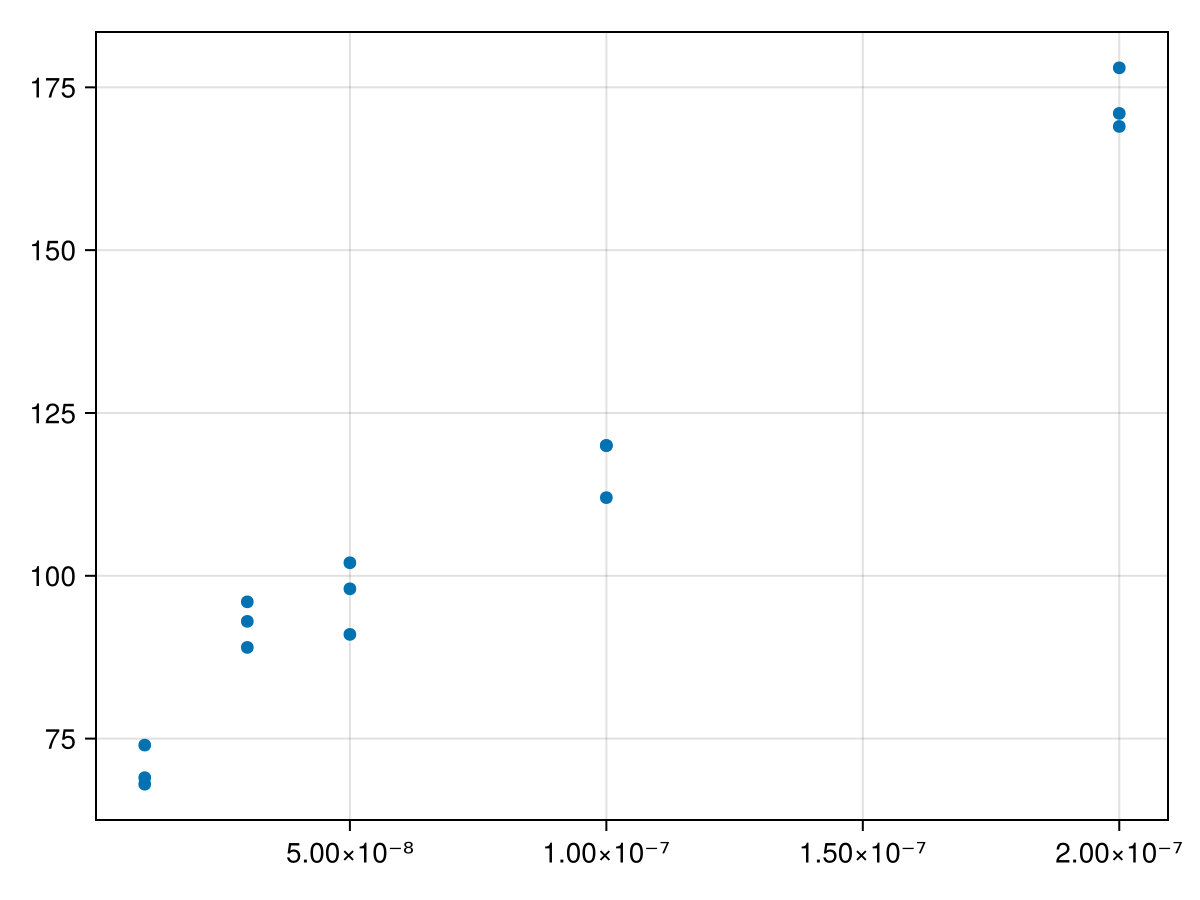

In [16]:
Bs = map(run_ids) do run_id
    TKE = joinpath("../../scratch/turbulence-at-many-fronts", run_id, "TKE.jld2")
    iterations, times = iterations_times(TKE)
    sp = simulation_parameters(TKE)
    sp.B
end
scatter(Bs, n_maxs)

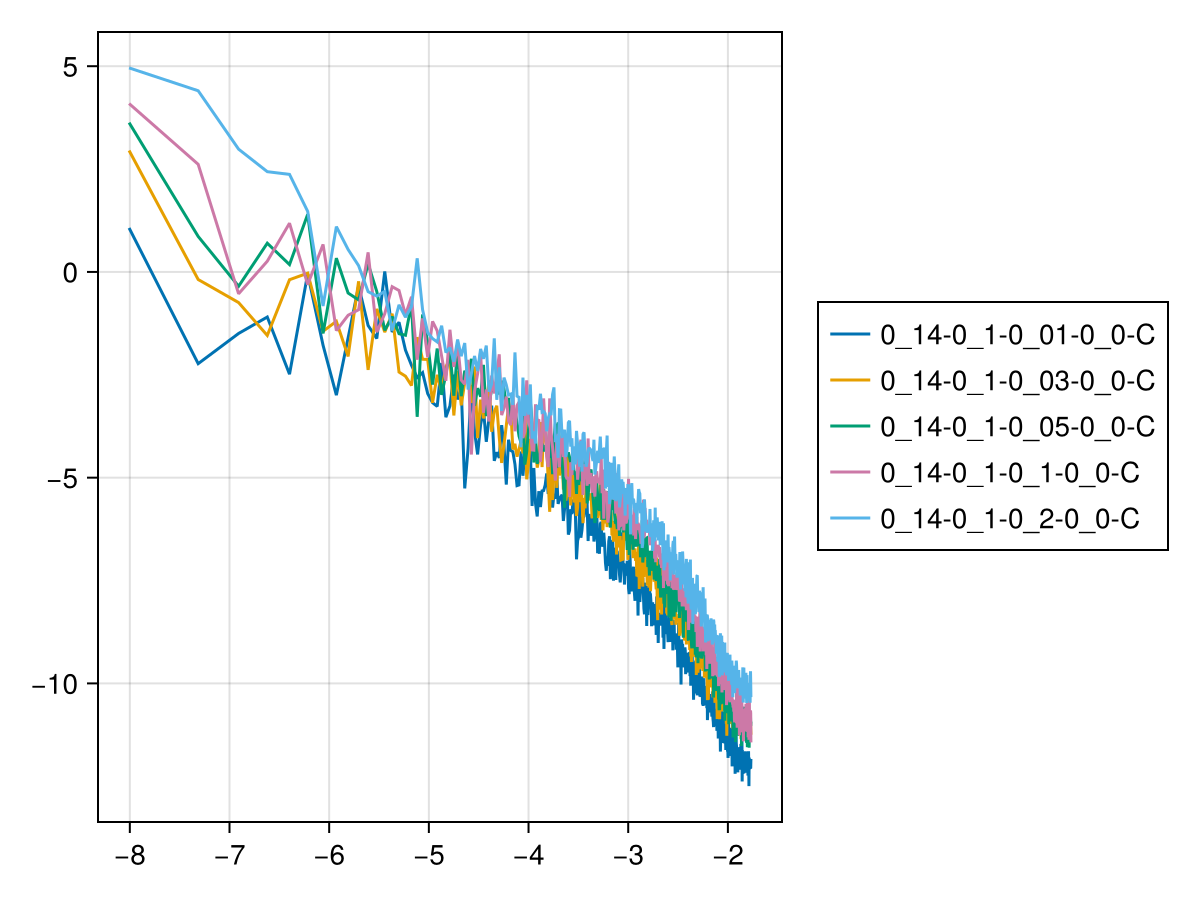

In [35]:
fig = Figure()
ax = Axis(fig[1, 1])
lns = map(11:15) do i
    TKE = joinpath("../../scratch/turbulence-at-many-fronts", run_ids[i], "DFM.jld2")
    iterations, times = iterations_times(TKE)
    sp = simulation_parameters(TKE)
    xsᶜ, xsᶠ, ysᶜ, ysᶠ, zsᶜ, zsᶠ = grid_nodes(TKE)
    inds = center_indices(TKE)
    data = get_field(TKE, "v_dfm", iterations[n_maxs[i]]) do field
        data = abs.(fftshift(fft(field[inds, end-40:end-10], 1))).^2
        mean(data; dims=2)[:, 1]
    end
    #data += get_field(TKE, "v", iterations[n_maxs[i]]) do field
    #    data = abs.(fftshift(fft(field[inds, :, end-40:end-10], 1))).^2
    #    mean(data; dims=(2, 3))[:, 1, 1]
    #end
    ks = fftshift(fftfreq(length(inds), sp.Nh / sp.Lh))
    lines!(ax, log.(ks[514:end]), log.(data[514:end]))
end
Legend(fig[1, 2], lns, run_ids[11:15])
fig

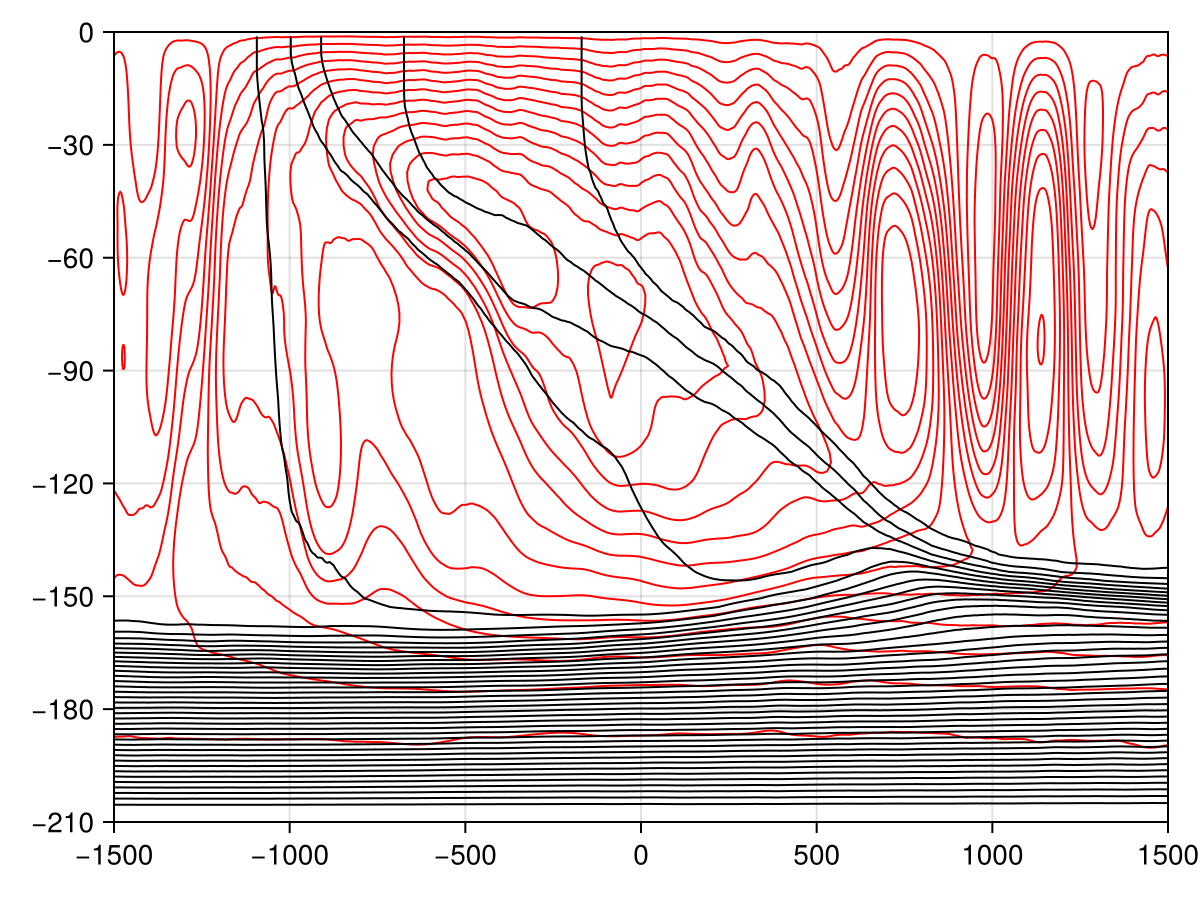

In [149]:
i = 12
TKE = joinpath("../../scratch/turbulence-at-many-fronts", run_ids[i], "COARSE.jld2")
iterations, times = iterations_times(TKE)
sp = simulation_parameters(TKE)
xsᶜ, xsᶠ, ysᶜ, ysᶠ, zsᶜ, zsᶠ = grid_nodes(TKE)
inds = center_indices(TKE)
data = get_field(TKE, "ψ_coarse", iterations[end]) do field
    field# .- filt(field, 200, 0)
end
fig = Figure()
ax = Axis(fig[1, 1];
    limits = (-sp.Lh/2, sp.Lh/2, -sp.Lz, 0)
)
contour!(ax, xsᶠ, zsᶠ, data; color=:red, levels=20)

data = get_field(TKE, "b_coarse", iterations[end]) do field
    cumsum(map(a->max(a, 0), diff(filt(field, 0, 1); dims=2)); dims=2)
end
contour!(ax, xsᶜ, zsᶜ[2:end], data[:, 1:end]; color=:black, levels=40)
fig

In [140]:
function mld_k(b)
    b = cumsum(map(a->max(a, 0), diff(filt(b, 0, 1); dims=2)); dims=2)
    ks = map(k->sum(abs.(mean(b[:, end-k:end]; dims=2)[:, 1] .- b[:, end])), 1:(size(b, 2)-1))
end

mld_k (generic function with 1 method)

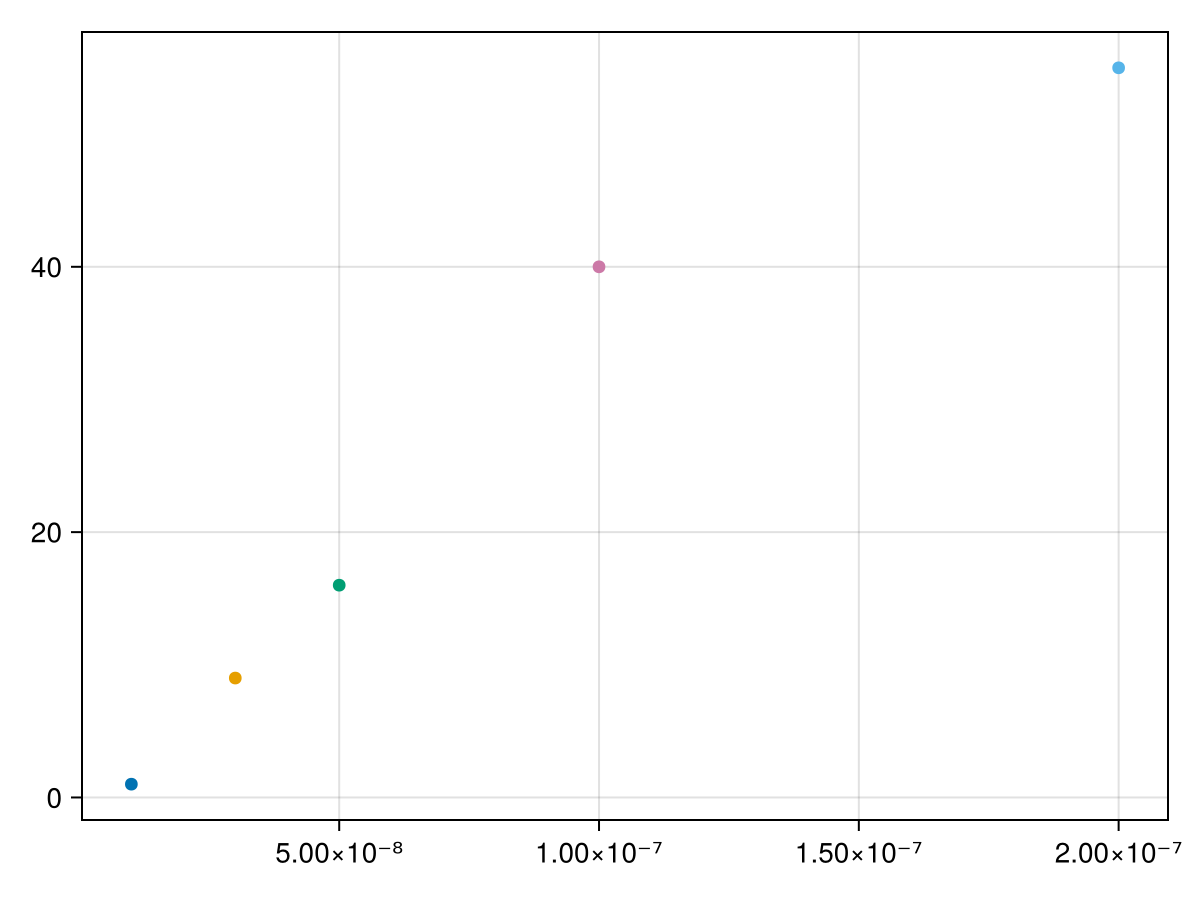

In [164]:
fig = Figure()
ax = Axis(fig[1, 1])
lns = map(11:15) do i
    TKE = joinpath("../../scratch/turbulence-at-many-fronts", run_ids[i], "COARSE.jld2")
    iterations, times = iterations_times(TKE)
    sp = simulation_parameters(TKE)
    xsᶜ, xsᶠ, ysᶜ, ysᶠ, zsᶜ, zsᶠ = grid_nodes(TKE)
    inds = center_indices(TKE)
    data = get_field(TKE, "b_coarse", iterations[end]) do field
        mld_k(field)
    end;
    k = findfirst(diff(data) .> 0.0001)
    scatter!(ax, sp.B, k)
end
#Legend(fig[1, 2], lns, run_ids[6:10])
fig

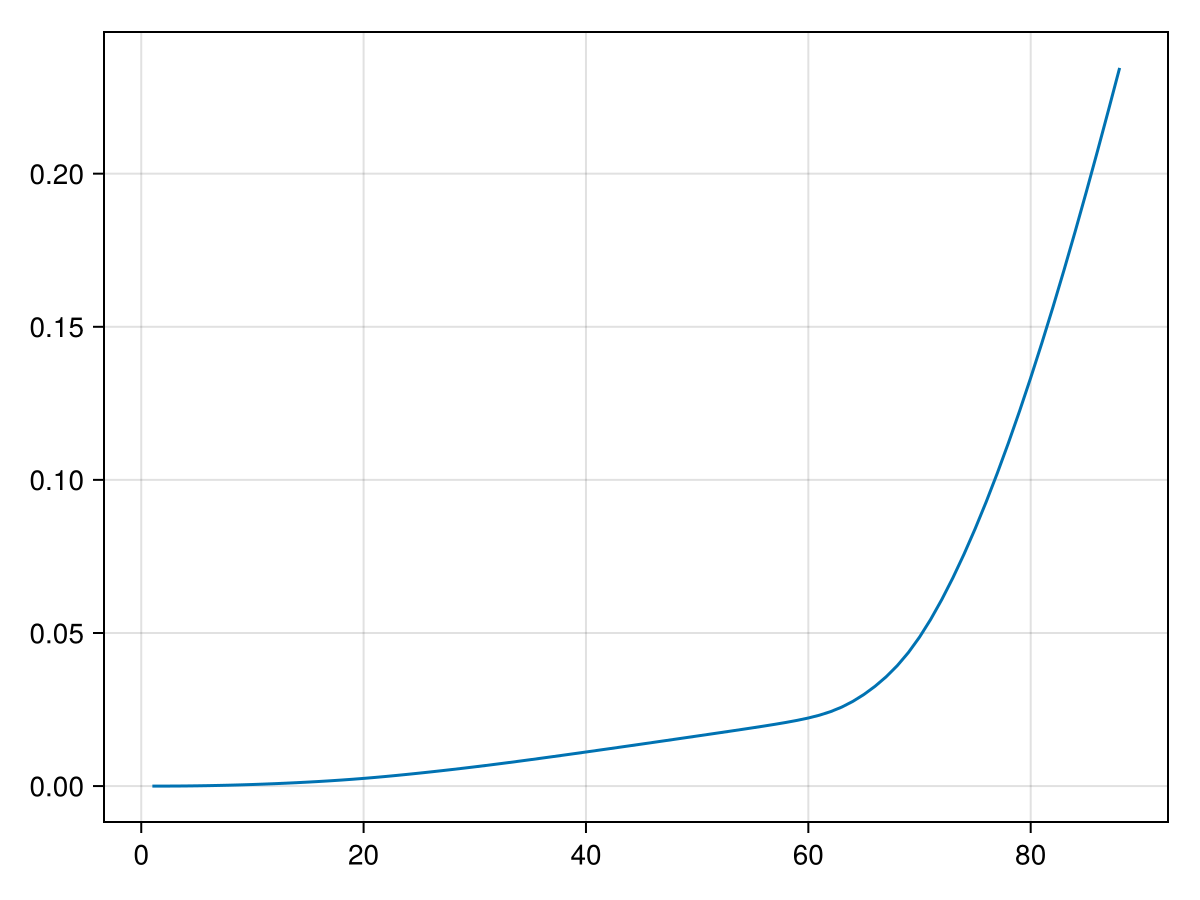

In [151]:
lines(data)

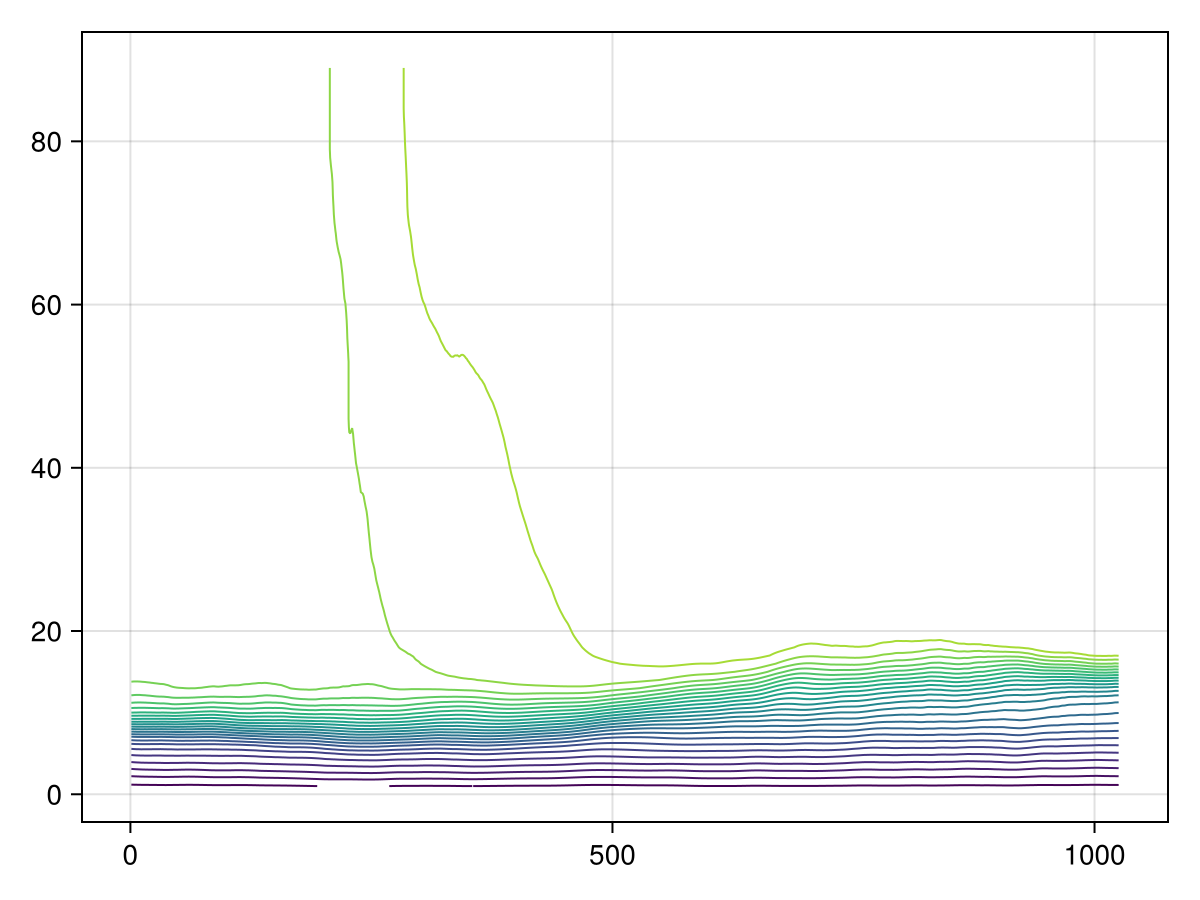

In [122]:
contour(data[inds, :] ./ sp.Δb; levels=-50:0.166:4)